Total Cloud Cost: $ 45.5

Cost by Energy Type
energy_type
Wind     23.8059
Solar    14.8629
Grid      6.8304
Name: total_cost, dtype: float64

Cost by Service
service
EC2       24.4067
Lambda    15.0021
S3         6.0904
Name: total_cost, dtype: float64

Daily Cost
timestamp
2026-01-01     0.4500
2026-02-01     1.5708
2026-03-01     5.2596
2026-04-01    13.4749
2026-05-02     8.5767
Name: total_cost, dtype: float64

Monthly Cost
timestamp
2026-01     0.4500
2026-02     1.5708
2026-03     5.2596
2026-04    13.4749
2026-05     8.5767
2026-06     4.6704
2026-07     1.4200
2026-08    10.0768
Freq: M, Name: total_cost, dtype: float64

Anomalies
Empty DataFrame
Columns: [timestamp, service, energy_type, usage_hours, cost_per_hour, total_cost]
Index: []

Idle Resources
Empty DataFrame
Columns: [timestamp, service, energy_type, usage_hours, cost_per_hour, total_cost]
Index: []


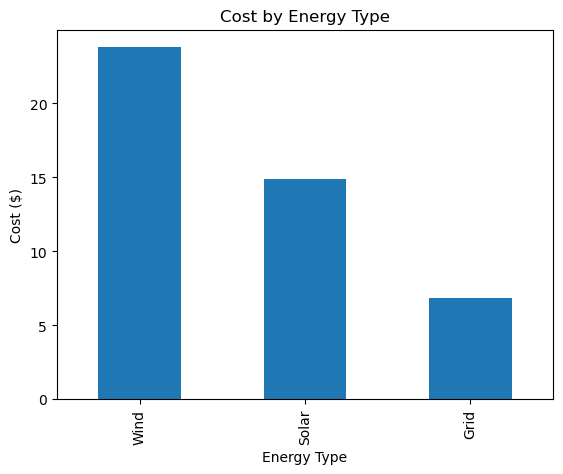

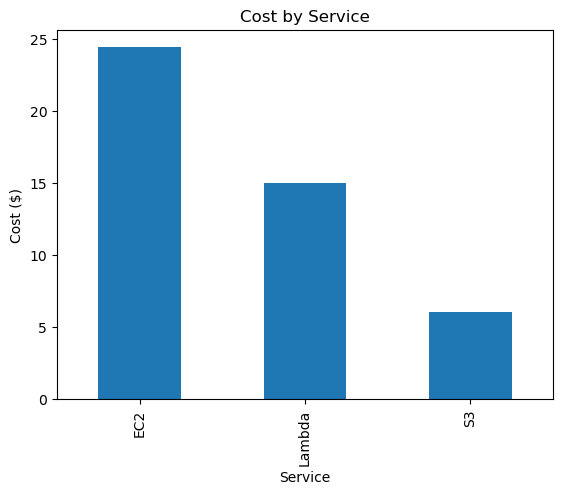

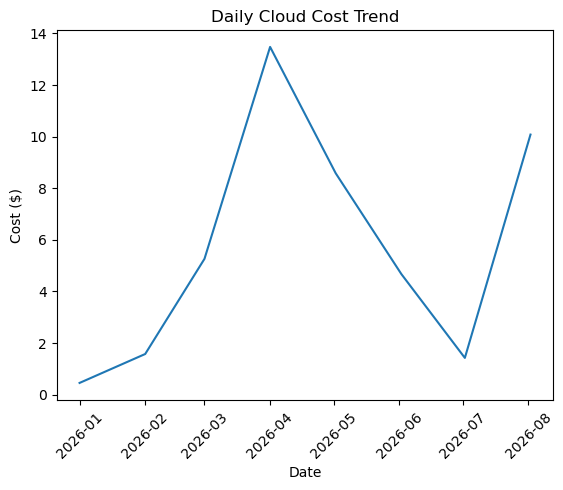

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
file_path = r"C:\Users\More\Downloads\energy_cloud_usage.xlsx"
df = pd.read_excel(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['total_cost'] = df['usage_hours'] * df['cost_per_hour']
total_cost = df['total_cost'].sum()
print("Total Cloud Cost: $", round(total_cost, 2))
cost_by_energy = df.groupby('energy_type')['total_cost'].sum().sort_values(ascending=False)
print("\nCost by Energy Type")
print(cost_by_energy)
cost_by_service = df.groupby('service')['total_cost'].sum().sort_values(ascending=False)
print("\nCost by Service")
print(cost_by_service)
daily_cost = df.groupby(df['timestamp'].dt.date)['total_cost'].sum()
print("\nDaily Cost")
print(daily_cost.head())
monthly_cost = df.groupby(df['timestamp'].dt.to_period('M'))['total_cost'].sum()
print("\nMonthly Cost")
print(monthly_cost)
threshold = df['total_cost'].mean() * 2
anomalies = df[df['total_cost'] > threshold]
print("\nAnomalies")
print(anomalies)
idle_resources = df[df['usage_hours'] < 1]
print("\nIdle Resources")
print(idle_resources)
cost_by_energy.plot(kind='bar')
plt.title("Cost by Energy Type")
plt.ylabel("Cost ($)")
plt.xlabel("Energy Type")
plt.show()
cost_by_service.plot(kind='bar')
plt.title("Cost by Service")
plt.ylabel("Cost ($)")
plt.xlabel("Service")
plt.show()
daily_cost.plot()
plt.title("Daily Cloud Cost Trend")
plt.ylabel("Cost ($)")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.show()
output_file = "cost_analysis_output.xlsx"
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    cost_by_energy.to_excel(writer, sheet_name='Cost by Energy')
    cost_by_service.to_excel(writer, sheet_name='Cost by Service')
    daily_cost.to_excel(writer, sheet_name='Daily Cost')
    monthly_cost.to_excel(writer, sheet_name='Monthly Cost')
    anomalies.to_excel(writer, sheet_name='Anomalies')
    idle_resources.to_excel(writer, sheet_name='Idle Resources')